# 22_因果机器学习-条件平均处理效应：S、T、X-Learner

## Notebook 使用说明

这是因果学习系列的第 14 份，也是“22. 因果机器学习”的第 4 份。建议先阅读本章《03. 双重机器学习与交互回归模型》，并熟悉回归树、集成回归与训练集、测试集的区别。本篇需要 NumPy、pandas、Matplotlib、SciPy 和 scikit-learn：`python -m pip install numpy pandas matplotlib scipy scikit-learn`。

CATE 的定义与识别依据参考资料 [1] 第 10.3 节、[2] 第 14.1 节；S、T、X-Learner 主要对应 [2] 第 15.1 节。主案例沿用 [2] 例 15.1.1 的三个数据生成式，包括 5%／95% 的处理概率、区间跳变和标准差为 0.05 的噪声。这里使用明确给定参数的直方图梯度提升树，不复现原书图中各软件的具体数值。零效应对照、观察性模拟、小表和练习是另设的教学构造。

书中用 $Z$ 表示完整调整变量，用其子集 $X$ 定义较低维的 CATE。为接续前几篇，本篇主分析仍用 $X$ 表示完整调整变量，低维子集另记为 $V$。主分析的 S/T 直接取同一特征下的预测差，不再额外平滑一次；这一直接形式也见 [3–4]。书中最后的低维条件平均步骤在练习二单独说明。X-Learner 同时展示常规实现和第一阶段交叉拟合的实现，不将两者混称。

所有数据由代码生成，不读取外部文件，也不依赖前面 Notebook 的变量或辅助模块。默认在 500 人和 2,000 人两种样本量下，对四种机制各做 150 次独立训练样本模拟；其中小样本的前三种机制再各比较 50 次交叉拟合。测试数据和用于画曲线的网格不参与拟合或调参。代码输出和图形均已保存；重新运行请使用 Restart Kernel and Run All Cells，修改参数后以新的输出为准。

In [1]:
# 环境初始化：本篇只生成数据；限制计算线程，避免重复拟合占满所有核心。
import os
import sys
import tempfile
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display
import scipy
from scipy.special import expit
import sklearn
from sklearn.base import clone, is_regressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error
from threadpoolctl import threadpool_limits

%matplotlib inline

_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [
    f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei",
                "SimHei", "Noto Sans CJK SC", "Noto Sans CJK JP"]
    if f in _available_fonts
] + ["DejaVu Sans"]
plt.rcParams.update({
    "font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
    "figure.dpi": 100, "figure.max_open_warning": 30,
})
pd.set_option("display.max_columns", 12)
pd.set_option("display.width", 150)
_thread_limit = threadpool_limits(limits=1)

SEED_DATA = 42
SEED_TEST = 2026
SEED_REPEAT = 2027
SEED_CROSSFIT = 2028
SEED_OBS = 2029
SEED_LEARNER = 99
N_MAIN = 500
N_TEST = 5000
N_GRID = 1000
SAMPLE_SIZES = (500, 2000)
N_REPEATS = 150
N_CROSS_REPEATS = 50
N_FOLDS = 3
N_OBS = 3000
METHODS = ("S", "T", "X")

if N_REPEATS < 2 or not 2 <= N_CROSS_REPEATS <= N_REPEATS:
    raise ValueError("重复模拟至少两次，交叉拟合比较次数不能超过主模拟次数。")
print(f"Python {sys.version.split()[0]}")
print(f"NumPy {np.__version__} | pandas {pd.__version__} | Matplotlib {plt.matplotlib.__version__}")
print(f"SciPy {scipy.__version__} | scikit-learn {sklearn.__version__}")

Python 3.13.5
NumPy 2.3.5 | pandas 2.2.3 | Matplotlib 3.10.8
SciPy 1.17.0 | scikit-learn 1.8.0


前面估计的是一个平均数。现在的问题变成：对于一组给定的特征，处理平均带来多大变化？培训后收入最高的人，未必是从培训中获益最多的人；预测收入与预测培训带来的收入差，是两个任务。

下面先看一个小表，再把已有的回归器分别安排成一条、两条和交叉补全的预测路径。算法名称里的 S、T、X，主要说明怎样组织回归问题，而不是换了一种全新的回归器。

## 理论基础

### 1. 条件平均效应，仍然是“平均”

令 $T\in\{0,1\}$ 表示处理，$X$ 为完整的处理前调整变量。目标函数为

$$
\tau(x)=E[Y(1)-Y(0)\mid X=x].
$$

在一致性、无干扰、条件可忽略性 $Y(t)\perp T\mid X$ 和相应的重叠条件下，

$$
\tau(x)=\mu_1(x)-\mu_0(x),\qquad
\mu_t(x)=E[Y\mid T=t,X=x].
$$

它不是某个具体人的 $Y_i(1)-Y_i(0)$。即使两个人的记录特征完全相同，他们的个体效应也可以不同；CATE 只描述这些特征下的平均值。[1，第 10.3 节；2，第 14.1 节]

下面的潜在结局表只用来说明定义，不是后面学习器能读取的训练数据。

In [2]:
science = pd.DataFrame({
    "类别": ["A"] * 6 + ["B"] * 6,
    "Y0": np.arange(1, 13, dtype=float),
    "个体效应": [-2, -1, 0, -2, -1, 0, 0, 1, 2, 0, 1, 2],
})
science["Y1"] = science["Y0"] + science["个体效应"]
summary = science.groupby("类别", sort=False).agg(
    人数=("Y0", "size"), 平均Y0=("Y0", "mean"), 平均Y1=("Y1", "mean"),
    条件平均效应=("个体效应", "mean"), 最小个体效应=("个体效应", "min"),
    最大个体效应=("个体效应", "max"),
)
display(science[["类别", "Y0", "Y1", "个体效应"]])
display(summary)
print(f"全体平均效应：{science['个体效应'].mean():.1f}")
assert np.allclose(summary["条件平均效应"], [-1, 1])

,类别,Y0,Y1,个体效应
0,A,1.0,-1.0,-2
1,A,2.0,1.0,-1
2,A,3.0,3.0,0
3,A,4.0,2.0,-2
4,A,5.0,4.0,-1
5,A,6.0,6.0,0
6,B,7.0,7.0,0
7,B,8.0,9.0,1
8,B,9.0,11.0,2
9,B,10.0,10.0,0


,人数,平均Y0,平均Y1,条件平均效应,最小个体效应,最大个体效应
类别,,,,,,
A,6,3.5,2.5,-1.0,-2,0
B,6,9.5,10.5,1.0,0,2


全体平均效应：0.0


全体平均为零，却不是“对所有人都没有作用”。A 类平均为负，B 类平均为正，而同一类内部仍有个体差异。

现在要估计的是函数，而非单一系数。本篇主要检查函数预测误差，不把上一份 ATE 的标准误公式直接用作每个人的 CATE 标准误。这也对应 [2] 第 14.1 节对函数估计与平均效应推断的区分。

### 2. S-Learner：把处理也当作一个输入

用全体训练样本拟合一个结果模型 $\widehat g(t,x)$。预测时，对同一个 $x$ 分别输入两种处理：

$$
\widehat\tau_S(x)=\widehat g(1,x)-\widehat g(0,x).
$$

两次预测只能改变 $T$，不能拿一位接受者的特征与另一位对照的特征相减。若使用 $a+bT+c^\top X$ 这样的加性线性模型，预测差恒为 $b$，无论有多少特征，都不会得到随 $x$ 变化的效应。树模型可以通过不同分支表示交互；但若预测结局主要依赖其他变量，树也可能完全不使用 $T$。[2，第 15.1 节，S/T-Learner]

### 3. T-Learner：分别拟合两种结局

在对照中拟合 $\widehat\mu_0(x)$，在接受者中拟合 $\widehat\mu_1(x)$，然后

$$
\widehat\tau_T(x)=\widehat\mu_1(x)-\widehat\mu_0(x).
$$

这样不必让一个模型决定是否保留处理变量，但每个模型只能用一组样本。两组人数差很多时，较小一组的预测可能更不稳定。记两侧误差为 $a_t(x)=\widehat\mu_t(x)-\mu_t(x)$，则

$$
\widehat\tau_T(x)-\tau(x)=a_1(x)-a_0(x).
$$

误差可能抵消，也可能叠加。所以结局预测好，不等于两种结局的差一定预测得好。

### 4. X-Learner：先补缺失结局，再学习效应

第一步仍是 T-Learner 的两个结果模型。第二步为每个训练样本补上没有观察到的一侧：

$$
D_i^1=Y_i-\widehat\mu_0(X_i),\quad T_i=1;
\qquad
D_i^0=\widehat\mu_1(X_i)-Y_i,\quad T_i=0.
$$

两式的方向都是“处理减对照”。再分别回归这些伪结局：

$$
\widehat\tau_1(x)\leftarrow (X_i,D_i^1)_{T_i=1},\qquad
\widehat\tau_0(x)\leftarrow (X_i,D_i^0)_{T_i=0}.
$$

这里下标表示第二阶段使用哪一组样本，不表示“处理为 1 时的效应”与“处理为 0 时的效应”是两个不同因果量。在完整调整变量条件下，两条路径都以同一个 $\tau(x)$ 为目标。[2，第 15.1 节，X-Learner]

最后采用书中的评分组合：

$$
\widehat\tau_X(x)
=[1-\widehat e(x)]\widehat\tau_1(x)+\widehat e(x)\widehat\tau_0(x).
$$

若 $e(x)$ 小，对照多，$\widehat\mu_0$ 往往更容易估计；此时更重视利用这一模型构造的 $D^1$ 路径。权重较大的是 $\widehat\tau_1$，不是 $\widehat\tau_0$。它仍要在少量接受者中学习效应，只有当效应函数相对简单等条件合适时，这样分工才可能有利。评分是组合权重，不是 AIPW 的残差纠偏项，也不是自动最优的方差权重。[2，第 15.1 节，例 15.1.1 与 Qualitative Comparison]

## 完整案例一：12 行数据，逐步补全

先用没有噪声的小表核对符号。指定未处理均值为 $2+3x$，效应为 $1+0.5x$。每一行只保留实际处理下的结局；用两组各自的数据拟合结果回归。

In [3]:
tiny = pd.DataFrame({
    "X": np.repeat([0., 1., 2.], 4),
    "T": [0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1],
})
tiny["Y"] = 2 + 3 * tiny["X"] + tiny["T"] * (1 + .5 * tiny["X"])
xt = tiny[["X"]].to_numpy()
tt = tiny["T"].to_numpy()
yt = tiny["Y"].to_numpy()
tiny_mu0 = LinearRegression().fit(xt[tt == 0], yt[tt == 0])
tiny_mu1 = LinearRegression().fit(xt[tt == 1], yt[tt == 1])
pred0, pred1 = tiny_mu0.predict(xt), tiny_mu1.predict(xt)
tiny_d1 = yt[tt == 1] - pred0[tt == 1]
tiny_d0 = pred1[tt == 0] - yt[tt == 0]
trace = tiny.copy()
trace["补上的缺失结局"] = np.where(tt == 1, pred0, pred1)
trace["伪结局"] = np.where(tt == 1, yt - pred0, pred1 - yt)
trace["进入的第二阶段"] = np.where(tt == 1, "tau1：接受者", "tau0：对照")
display(trace.round(3))

,X,T,Y,补上的缺失结局,伪结局,进入的第二阶段
0,0.0,0,2.0,3.0,1.0,tau0：对照
1,0.0,0,2.0,3.0,1.0,tau0：对照
2,0.0,0,2.0,3.0,1.0,tau0：对照
3,0.0,1,3.0,2.0,1.0,tau1：接受者
4,1.0,0,5.0,6.5,1.5,tau0：对照
5,1.0,0,5.0,6.5,1.5,tau0：对照
6,1.0,1,6.5,5.0,1.5,tau1：接受者
7,1.0,1,6.5,5.0,1.5,tau1：接受者
8,2.0,0,8.0,10.0,2.0,tau0：对照
9,2.0,1,10.0,8.0,2.0,tau1：接受者


接受者减去预测的未处理结局；对照则用预测的处理结局减去实际结局。下面训练两个效应模型，再到三组新的特征上做组合。这里的无噪声线性结构使两个结果模型恰好拟合正确；真实数据一般不会如此整齐。

In [4]:
tiny_tau1 = LinearRegression().fit(xt[tt == 1], tiny_d1)
tiny_tau0 = LinearRegression().fit(xt[tt == 0], tiny_d0)
xnew = np.array([[.25], [1.], [1.75]])
e_demo = np.array([.2, .5, .8])  # 只用于核对凸组合；不是从这个小表估计的总体评分。
p1 = tiny_tau1.predict(xnew)
p0 = tiny_tau0.predict(xnew)
tiny_result = pd.DataFrame({
    "新X": xnew[:, 0], "tau1": p1, "tau0": p0, "e": e_demo,
    "tau1权重": 1-e_demo, "tau0权重": e_demo,
    "X组合": (1-e_demo)*p1 + e_demo*p0,
    "T预测差": tiny_mu1.predict(xnew)-tiny_mu0.predict(xnew),
    "指定效应": 1+.5*xnew[:, 0],
})
display(tiny_result.round(4))
assert np.allclose(tiny_result["X组合"], tiny_result["指定效应"])
assert np.allclose(tiny_result["T预测差"], tiny_result["指定效应"])

,新X,tau1,tau0,e,tau1权重,tau0权重,X组合,T预测差,指定效应
0,0.25,1.125,1.125,0.2,0.8,0.2,1.125,1.125,1.125
1,1.00,1.500,1.500,0.5,0.5,0.5,1.500,1.500,1.500
2,1.75,1.875,1.875,0.8,0.2,0.8,1.875,1.875,1.875


这里两条效应路径都正确，怎么取凸组合都一样。但只要一条路径有误差，权重就会影响答案。这不是“双重稳健”：评分正确，并不能使任意错误的结果预测自动得到纠正。

还有一个名字容易混淆：X-Learner 的 X 指这种交叉补全的结构，不等于 K 折交叉拟合。常规 X-Learner 用对照训练 $\widehat\mu_0$，再给接受者补结局，已经没有直接用该接受者的结局训练这个对照模型；但它不是前两篇的完整 K 折数据流程。[2，第 15.1 节及备注 15.1.1；3–4]

## 完整案例二：处理很少，基线却有一个跳变

### 1. 沿用原书的三种机制

令 $X\sim U(0,1)$，$B(X)=\mathbb{1}\{0.6\leq X\leq0.8\}$，独立噪声 $\varepsilon\sim N(0,0.05^2)$。本篇按 [2] 例 15.1.1 实现：

| 机制 | 结果生成式 | 处理概率 | 困难在哪里 |
|---|---|---:|---|
| DGP 1 | $Y=0.3B(X)+0.5T+\varepsilon$ | 0.05 | 基线有跳变，效应恒定 |
| DGP 2 | $Y=0.1+0.5B(X)T+\varepsilon$ | 0.05 | 基线简单，效应有跳变，接受者少 |
| DGP 3 | $Y=0.1+0.5B(X)T+\varepsilon$ | 0.95 | 同样的跳变效应，接受者多 |

另加一个零效应对照：$Y=0.3B(X)+\varepsilon$、$e=0.5$，检查模型会不会把随机差异学成异质性。前三种机制来自原书，第四种由本篇增设。都满足随机分配；先不混入未测混杂，让差别集中在回归任务与样本量上。

,X,T,Y
0,0.7740,0,0.2629
1,0.4389,0,0.0462
2,0.8586,0,0.0017
3,0.6974,0,0.2859
4,0.0942,0,-0.0053
5,0.9756,0,0.0112
6,0.7611,0,0.3308
7,0.7861,0,0.2500


,人数,平均结局
T,,
0,469,0.0671
1,31,0.5374


特征区域,跳变区间内,跳变区间外
T,,
0,103,366
1,4,27


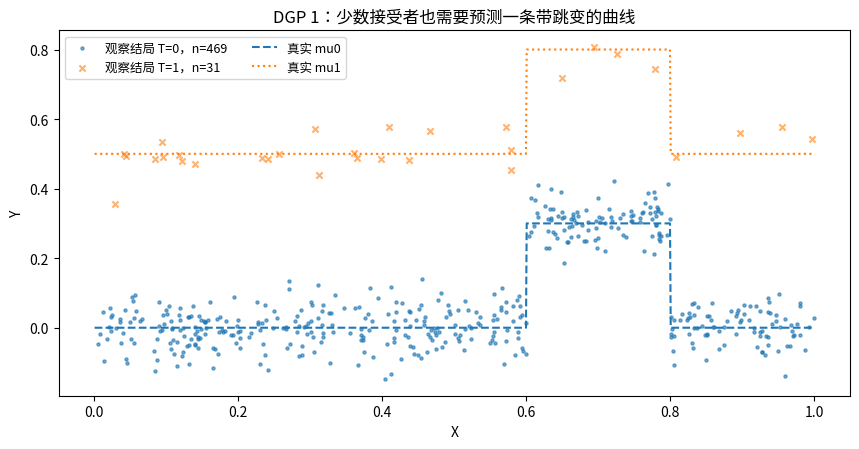

In [5]:
DGP_NAMES = {
    1: "DGP 1：复杂基线，e=0.05",
    2: "DGP 2：跳变效应，e=0.05",
    3: "DGP 3：跳变效应，e=0.95",
    4: "零效应对照，e=0.50",
}

def book_functions(x: np.ndarray, mechanism: int) -> dict:
    x = np.asarray(x, dtype=float)
    if x.ndim != 2 or x.shape[1] != 1 or not np.isfinite(x).all():
        raise ValueError("本组生成式需要有限的一列特征。")
    if np.any((x < 0) | (x > 1)):
        raise ValueError("X 应位于 [0,1]。")
    bump = ((x[:, 0] >= .6) & (x[:, 0] <= .8)).astype(float)
    if mechanism == 1:
        mu0, tau, p = .3*bump, np.full(len(x), .5), .05
    elif mechanism in (2, 3):
        mu0, tau = np.full(len(x), .1), .5*bump
        p = .05 if mechanism == 2 else .95
    elif mechanism == 4:
        mu0, tau, p = .3*bump, np.zeros(len(x)), .5
    else:
        raise ValueError("mechanism 只能是 1、2、3、4。")
    return {"mu0": mu0, "mu1": mu0+tau, "tau": tau, "p": p}

def make_book_data(n: int, mechanism: int, seed: int) -> tuple:
    if not isinstance(n, (int, np.integer)) or n < 4:
        raise ValueError("n 必须是至少为 4 的整数。")
    rng = np.random.default_rng(seed)
    x = rng.uniform(0, 1, (n, 1))
    truth = book_functions(x, mechanism)
    t = rng.binomial(1, truth["p"], n)
    y = truth["mu0"] + t*truth["tau"] + rng.normal(0, .05, n)
    observed = pd.DataFrame({"X": x[:, 0], "T": t, "Y": y})
    return observed, truth  # 真值与观察表分开；学习器只接收 observed。

observed, truth = make_book_data(N_MAIN, 1, SEED_DATA)
test, test_truth = make_book_data(N_TEST, 1, SEED_TEST)
x = observed[["X"]].to_numpy()
t = observed["T"].to_numpy()
y = observed["Y"].to_numpy()
x_test = test[["X"]].to_numpy()
grid = ((np.arange(N_GRID)+.5)/N_GRID)[:, None]
grid_truth = book_functions(grid, 1)
display(observed.head(8).round(4))
display(observed.groupby("T").agg(人数=("Y", "size"), 平均结局=("Y", "mean")).round(4))
region = np.where(observed["X"].between(.6, .8), "跳变区间内", "跳变区间外")
display(pd.crosstab(observed["T"], region, colnames=["特征区域"]))

fig, ax = plt.subplots(figsize=(8.7, 4.6))
for state, marker in [(0, "."), (1, "x")]:
    ax.scatter(x[t == state, 0], y[t == state], s=20, alpha=.6, marker=marker,
               label=f"观察结局 T={state}，n={np.sum(t == state)}")
ax.plot(grid[:, 0], grid_truth["mu0"], "--", label="真实 mu0")
ax.plot(grid[:, 0], grid_truth["mu1"], ":", label="真实 mu1")
ax.set(xlabel="X", ylabel="Y", title="DGP 1：少数接受者也需要预测一条带跳变的曲线")
ax.legend(ncol=2, fontsize=9)
fig.tight_layout()
plt.show()

图里的两条真实均值曲线始终相差 0.5。但是接受者很少，单凭这些点，不容易确定跳变的位置。原书在正文第 406 页的图 15.1–15.2 用这一结构解释 X-Learner 的分工；下面保留该生成式，重新用当前 Python 学习器计算结果。[2，图 15.1–15.2、例 15.1.1]

### 2. 先写 S 与 T 的结果模型

各方法使用同一配置的 `HistGradientBoostingRegressor`：60 次提升、每棵树最多 7 个叶节点、叶节点至少 10 人，关闭自动早停。选择这些参数是为了让实验规模可控、各方法可比较，不是根据测试真值寻找最优配置。[5]

下面的辅助函数只做输入检查与组织拟合。每次使用 `clone` 新建模型，避免 S、T 或两侧结果模型意外共用同一个已拟合对象。

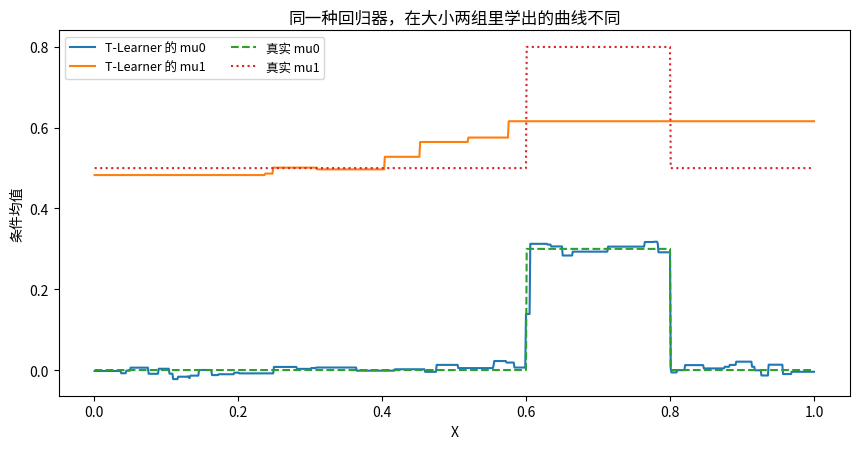

In [6]:
def check_arrays(x: np.ndarray, t: np.ndarray, y: np.ndarray) -> tuple:
    x, t, y = np.asarray(x, float), np.asarray(t), np.asarray(y, float)
    if x.ndim != 2 or x.shape[1] < 1 or t.ndim != 1 or y.ndim != 1:
        raise ValueError("X 应为二维，T 与 Y 应为一维。")
    if not len(x) == len(t) == len(y) or len(y) < 4:
        raise ValueError("行数不一致或样本太少。")
    if not np.isfinite(x).all() or not np.isfinite(y).all():
        raise ValueError("X 与 Y 不能包含缺失或无限值。")
    if not np.isin(t, [0, 1]).all() or min(np.sum(t == 0), np.sum(t == 1)) < 2:
        raise ValueError("T 必须为 0/1，且每组至少两人；不会自动重抽样直到通过。")
    return x, t.astype(int), y

def base_regressor():
    return HistGradientBoostingRegressor(
        max_iter=60, learning_rate=.08, max_leaf_nodes=7,
        min_samples_leaf=10, l2_regularization=.1,
        early_stopping=False, random_state=SEED_LEARNER,
    )

def fit_responses(x: np.ndarray, t: np.ndarray, y: np.ndarray, regressor) -> dict:
    x, t, y = check_arrays(x, t, y)
    if not is_regressor(regressor):
        raise TypeError("本篇连续结局实现需要回归器，不接收分类标签预测器。")
    model_s = clone(regressor).fit(np.column_stack([x, t]), y)
    model0 = clone(regressor).fit(x[t == 0], y[t == 0])
    model1 = clone(regressor).fit(x[t == 1], y[t == 1])
    return {"s": model_s, "mu0": model0, "mu1": model1, "n_features": x.shape[1]}

def predict_responses(models: dict, xnew: np.ndarray) -> dict:
    xnew = np.asarray(xnew, float)
    if xnew.ndim != 2 or xnew.shape[1] != models["n_features"] or not np.isfinite(xnew).all():
        raise ValueError("新样本的特征维度不符，或含非有限值。")
    n = len(xnew)
    s0 = models["s"].predict(np.column_stack([xnew, np.zeros(n)]))
    s1 = models["s"].predict(np.column_stack([xnew, np.ones(n)]))
    m0, m1 = models["mu0"].predict(xnew), models["mu1"].predict(xnew)
    return {"S0": s0, "S1": s1, "mu0": m0, "mu1": m1, "S": s1-s0, "T": m1-m0}

responses = fit_responses(x, t, y, base_regressor())
response_grid = predict_responses(responses, grid)
fig, ax = plt.subplots(figsize=(8.7, 4.6))
for name, linestyle in [("mu0", "-"), ("mu1", "-")]:
    ax.plot(grid[:, 0], response_grid[name], linestyle, label=f"T-Learner 的 {name}")
ax.plot(grid[:, 0], grid_truth["mu0"], "--", label="真实 mu0")
ax.plot(grid[:, 0], grid_truth["mu1"], ":", label="真实 mu1")
ax.set(xlabel="X", ylabel="条件均值", title="同一种回归器，在大小两组里学出的曲线不同")
ax.legend(ncol=2, fontsize=9)
fig.tight_layout()
plt.show()

### 3. 给 X-Learner 构造两组伪结局

默认样本中，跳变区间内有 103 位对照、4 位接受者。每个叶节点至少需要 10 人，处理侧模型无法单独给这 4 人建立一个叶节点；对照侧则有足够样本描出这段变化。这解释了上图在当前配置下的差别，不是两条真实曲线的复杂度不同。

先调用刚才的结果模型，再分别计算 $D^0$ 与 $D^1$。常规版本直接用完整对照／接受者训练的结果模型；交叉拟合版本则只从其他折取得结果预测。两种情况下，第二阶段都使用当前训练样本，而不使用测试结局。

下方同时保留每折训练人数和伪结局，便于检查。评分可传入实验已知的概率，也可传入仅在训练样本拟合的分类器；后者的 `predict_proba` 用于组合，不传入 0/1 分类结果。

,X,T,Y,补上的缺失结局,伪结局
0,0.7740,0,0.2629,0.6160,0.3532
1,0.4389,0,0.0462,0.5280,0.4818
2,0.8586,0,0.0017,0.6160,0.6143
3,0.6974,0,0.2859,0.6160,0.3302
26,0.4667,1,0.5657,-0.0044,0.5701
27,0.0438,1,0.4945,-0.0080,0.5025
40,0.4372,1,0.4813,0.0020,0.4793
43,0.3124,1,0.4383,0.0063,0.4320


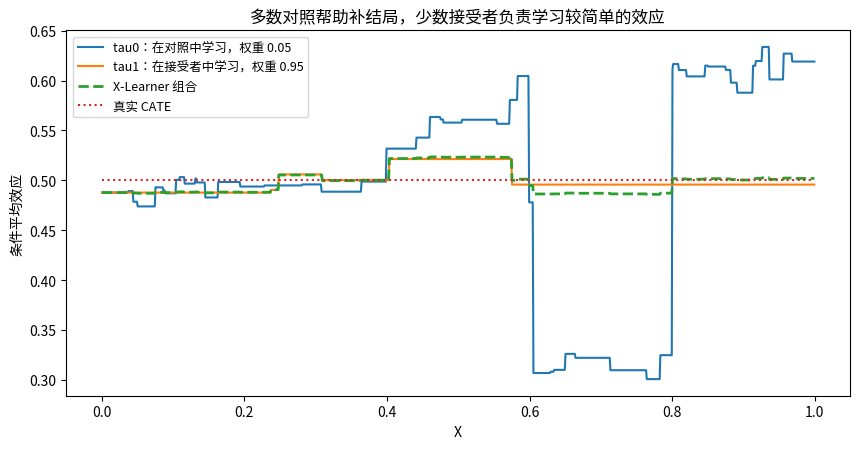

In [7]:
def fit_x_learner(x: np.ndarray, t: np.ndarray, y: np.ndarray, responses: dict,
                  outcome_regressor, effect_regressor, propensity,
                  n_folds: int = 0, split_seed: int = SEED_CROSSFIT) -> dict:
    x, t, y = check_arrays(x, t, y)
    if not is_regressor(effect_regressor):
        raise TypeError("第二阶段需要回归器，因为伪结局不是分类标签。")
    if not isinstance(n_folds, (int, np.integer)) or n_folds < 0 or n_folds == 1:
        raise ValueError("n_folds 应为 0，或至少为 2 的整数。")
    fold_rows, split_list = [], []
    if n_folds == 0:
        m0, m1 = responses["mu0"].predict(x), responses["mu1"].predict(x)
        fold_id = np.full(len(y), -1, dtype=int)
    else:
        if min(np.sum(t == 0), np.sum(t == 1)) < n_folds:
            raise ValueError("较小组的人数少于折数。")
        m0, m1 = np.full(len(y), np.nan), np.full(len(y), np.nan)
        fold_id = np.full(len(y), -1, dtype=int)
        split_list = list(StratifiedKFold(n_folds, shuffle=True, random_state=split_seed).split(x, t))
        for k, (train, holdout) in enumerate(split_list):
            i0, i1 = train[t[train] == 0], train[t[train] == 1]
            if min(len(i0), len(i1)) < 2:
                raise ValueError("某折中的结果模型训练组少于两人。")
            assert not np.intersect1d(train, holdout).size
            assert np.all(fold_id[holdout] == -1)
            m0[holdout] = clone(outcome_regressor).fit(x[i0], y[i0]).predict(x[holdout])
            m1[holdout] = clone(outcome_regressor).fit(x[i1], y[i1]).predict(x[holdout])
            fold_id[holdout] = k
            fold_rows.append({"折": k+1, "训练对照": len(i0), "训练接受者": len(i1),
                              "留出对照": int(np.sum(t[holdout] == 0)),
                              "留出接受者": int(np.sum(t[holdout] == 1))})
        assert np.all(fold_id >= 0) and np.isfinite(m0).all() and np.isfinite(m1).all()
    # 下标表示第二阶段的训练组；两个伪结局都采用“处理减对照”的方向。
    pseudo0 = m1[t == 0] - y[t == 0]
    pseudo1 = y[t == 1] - m0[t == 1]
    tau0 = clone(effect_regressor).fit(x[t == 0], pseudo0)
    tau1 = clone(effect_regressor).fit(x[t == 1], pseudo1)
    if isinstance(propensity, (int, float, np.integer, np.floating)):
        if not np.isfinite(propensity) or not 0 < float(propensity) < 1:
            raise ValueError("实验已知处理概率必须严格位于 (0,1)。")
        ps = float(propensity)
    else:
        ps = clone(propensity).fit(x, t)
        if not hasattr(ps, "predict_proba"):
            raise TypeError("评分模型需要提供 predict_proba。")
    return {"tau0": tau0, "tau1": tau1, "ps": ps, "n_features": x.shape[1],
            "pseudo0": pseudo0, "pseudo1": pseudo1, "m0_for_labels": m0,
            "m1_for_labels": m1, "fold_id": fold_id, "fold_audit": pd.DataFrame(fold_rows),
            "splits": split_list}

def predict_x(model: dict, xnew: np.ndarray) -> dict:
    xnew = np.asarray(xnew, float)
    if xnew.ndim != 2 or xnew.shape[1] != model["n_features"] or not np.isfinite(xnew).all():
        raise ValueError("新样本的特征维度不符，或含非有限值。")
    if isinstance(model["ps"], float):
        e = np.full(len(xnew), model["ps"])
    else:
        col = int(np.flatnonzero(np.asarray(model["ps"].classes_) == 1)[0])
        e = model["ps"].predict_proba(xnew)[:, col]
    if not np.isfinite(e).all() or np.any((e < 0) | (e > 1)):
        raise ValueError("评分模型没有返回有效概率。")
    tau0, tau1 = model["tau0"].predict(xnew), model["tau1"].predict(xnew)
    return {"tau0": tau0, "tau1": tau1, "e": e, "X": e*tau0+(1-e)*tau1}

x_model = fit_x_learner(x, t, y, responses, base_regressor(), base_regressor(), truth["p"])
trace_main = observed.copy()
trace_main["补上的缺失结局"] = np.where(t == 1, x_model["m0_for_labels"], x_model["m1_for_labels"])
trace_main["伪结局"] = np.where(t == 1, y-x_model["m0_for_labels"], x_model["m1_for_labels"]-y)
preview_idx = np.r_[np.flatnonzero(t == 0)[:4], np.flatnonzero(t == 1)[:4]]
display(trace_main.iloc[preview_idx].round(4))
x_grid = predict_x(x_model, grid)
fig, ax = plt.subplots(figsize=(8.7, 4.6))
ax.plot(grid[:, 0], x_grid["tau0"], label="tau0：在对照中学习，权重 0.05")
ax.plot(grid[:, 0], x_grid["tau1"], label="tau1：在接受者中学习，权重 0.95")
ax.plot(grid[:, 0], x_grid["X"], "--", linewidth=2, label="X-Learner 组合")
ax.plot(grid[:, 0], grid_truth["tau"], ":", label="真实 CATE")
ax.set(xlabel="X", ylabel="条件平均效应", title="多数对照帮助补结局，少数接受者负责学习较简单的效应")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

### 4. 在没有参加训练的数据上评价

因为这里是模拟，测试特征上的真实 $\tau(x)$ 已知，可以计算

$$
\widehat R_\tau=\frac1{n_{\mathrm{test}}}\sum_i
[\widehat\tau(X_i^{\mathrm{test}})-\tau(X_i^{\mathrm{test}})]^2.
$$

下表分别报告 CATE 的 MSE、其平方根，以及测试特征上的平均有符号误差。最后一个数接近零，也可能只是正负误差抵消。这里比较的是条件均值差，不是带有个体噪声的两份潜在结局之差。

真实数据不能直接算这个误差。本篇暂不展开第 15.2–15.3 节的评分、校准与 uplift；它们在后续验证专篇处理。也不根据这里的模拟真值去调模型参数。

In [8]:
response_test = predict_responses(responses, x_test)
x_test_predictions = predict_x(x_model, x_test)
main_predictions = {"S": response_test["S"], "T": response_test["T"], "X": x_test_predictions["X"]}
main_rows = []
for name, pred in main_predictions.items():
    error = pred-test_truth["tau"]
    main_rows.append({"方法": name, "CATE MSE": np.mean(error**2),
                      "CATE RMSE": np.sqrt(np.mean(error**2)),
                      "平均有符号误差": np.mean(error), "预测效应标准差": np.std(pred)})
main_evaluation = pd.DataFrame(main_rows).set_index("方法")
display(main_evaluation.round(6))
# 结局误差只在实际观察到的一侧计算。X 的最终输出不是一个完整的结果模型。
factual_rows = []
for name, p0, p1 in [("S", response_test["S0"], response_test["S1"]),
                     ("T", response_test["mu0"], response_test["mu1"])]:
    tf = test["T"].to_numpy()
    factual = np.where(tf == 1, p1, p0)
    factual_rows.append({"结果模型": name,
                         "测试结局MSE": mean_squared_error(test["Y"], factual),
                         "对照结局MSE": mean_squared_error(test.loc[tf == 0, "Y"], p0[tf == 0]),
                         "接受者结局MSE": mean_squared_error(test.loc[tf == 1, "Y"], p1[tf == 1])})
display(pd.DataFrame(factual_rows).set_index("结果模型").round(6))

,CATE MSE,CATE RMSE,平均有符号误差,预测效应标准差
方法,,,,
S,0.010226,0.101124,-0.011599,0.100456
T,0.010375,0.101856,-0.007818,0.101556
X,0.000162,0.012732,-0.001141,0.012681


,测试结局MSE,对照结局MSE,接受者结局MSE
结果模型,,,
S,0.003207,0.002648,0.012378
T,0.003313,0.002743,0.012671


默认这份独立测试集中，S、T 的 CATE MSE 约为 0.01023、0.01038，X 约为 0.000162。X 在这里减小了区间内外不应存在的效应波动。

不能把“预测效应标准差小”单独当成优点。DGP 1 的真实效应恒定，所以小波动有意义；换成跳变效应，过于平坦反而可能是漏掉异质性。

还有一个很直接的计算。设结果模型在两侧的预测误差为 $a_0(x),a_1(x)$。固定模型后，测试结局 MSE 超过不可约噪声的部分是

$$
E\{[1-e(X)]a_0(X)^2+e(X)a_1(X)^2\},
$$

CATE 的 MSE 则是 $E[(a_1(X)-a_0(X))^2]$。前者按实际分组概率评价，后者评价两侧的差。本篇用下面的固定误差构造核对这一区别，并不是额外拟合出的经验结论。

In [9]:
error_demo = pd.DataFrame({
    "模型": ["两侧一起高估 0.10", "仅处理侧高估 0.20"],
    "a0": [.10, 0.], "a1": [.10, .20],
})
e_demo_small = .05
error_demo["超出噪声的结局MSE"] = (1-e_demo_small)*error_demo["a0"]**2 + e_demo_small*error_demo["a1"]**2
error_demo["CATE MSE"] = (error_demo["a1"]-error_demo["a0"])**2
display(error_demo.round(4))
assert error_demo.loc[1, "超出噪声的结局MSE"] < error_demo.loc[0, "超出噪声的结局MSE"]
assert error_demo.loc[1, "CATE MSE"] > error_demo.loc[0, "CATE MSE"]

,模型,a0,a1,超出噪声的结局MSE,CATE MSE
0,两侧一起高估 0.10,0.1,0.1,0.010,0.00
1,仅处理侧高估 0.20,0.0,0.2,0.002,0.04


第二个模型的结局 MSE 更小，但 CATE 误差更大。这并不是说结果预测误差没有用，而是不能只凭全体结局预测的单一指标评价效应模型，尤其在少数处理组时。

### 5. 效应也变复杂，人数优势是否还在？

接着运行原书 DGP 2 与 DGP 3。两者的真实效应完全一样，只改变处理概率。所有学习器参数保持不变，不因为看到了跳变位置就添加一个区间指示变量。

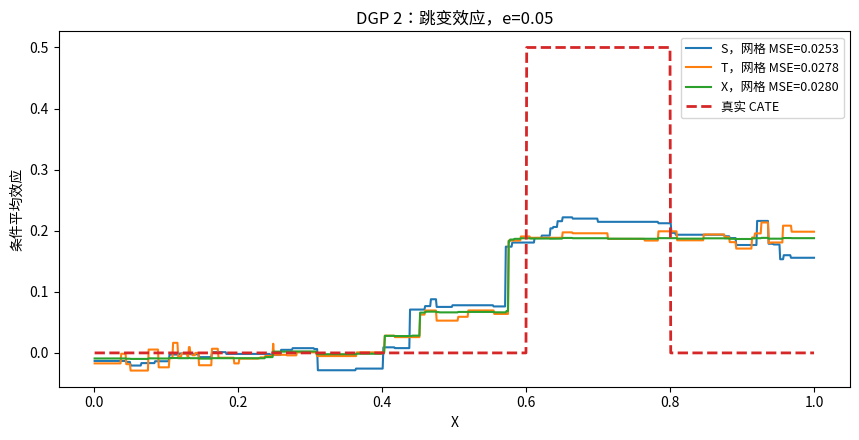

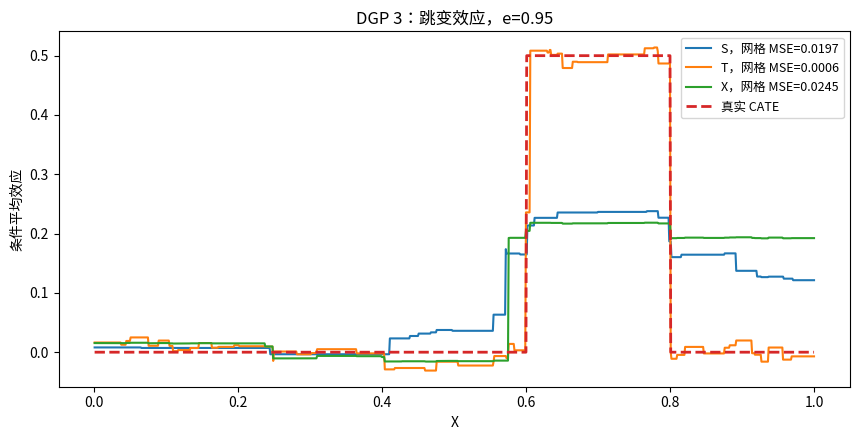

,机制,方法,网格CATE MSE,接受者人数,对照人数
0,2,S,0.025282,31,469
1,2,T,0.027831,31,469
2,2,X,0.028046,31,469
3,3,S,0.019664,469,31
4,3,T,0.000590,469,31
5,3,X,0.024453,469,31


In [10]:
case_models, case_evaluations = {}, []
for mechanism in [2, 3]:
    dat, known = make_book_data(N_MAIN, mechanism, SEED_DATA)
    xx, tt2, yy = dat[["X"]].to_numpy(), dat["T"].to_numpy(), dat["Y"].to_numpy()
    rr = fit_responses(xx, tt2, yy, base_regressor())
    xm = fit_x_learner(xx, tt2, yy, rr, base_regressor(), base_regressor(), known["p"])
    rp, xp = predict_responses(rr, grid), predict_x(xm, grid)
    true_grid = book_functions(grid, mechanism)["tau"]
    pp = {"S": rp["S"], "T": rp["T"], "X": xp["X"]}
    case_models[mechanism] = {"data": dat, "responses": rr, "x": xm, "predictions": pp}
    fig, ax = plt.subplots(figsize=(8.7, 4.5))
    for name, pred in pp.items():
        loss = float(np.mean((pred-true_grid)**2))
        ax.plot(grid[:, 0], pred, label=f"{name}，网格 MSE={loss:.4f}")
        case_evaluations.append({"机制": mechanism, "方法": name, "网格CATE MSE": loss,
                                 "接受者人数": int(tt2.sum()), "对照人数": int((1-tt2).sum())})
    ax.plot(grid[:, 0], true_grid, "--", linewidth=2, label="真实 CATE")
    ax.set(xlabel="X", ylabel="条件平均效应", title=DGP_NAMES[mechanism])
    ax.legend(fontsize=9)
    fig.tight_layout()
    plt.show()
display(pd.DataFrame(case_evaluations).round(6))

DGP 2 中，只有少数接受者提供区间内有处理结局的信息。X-Learner 没有凭空增加这部分信息。DGP 3 则让处理侧结果模型有机会从大量接受者中学到跳变；但 X 的组合更重视在少量对照中学习的效应路径，第二阶段的平滑可能抹掉跳变。

原书用这组机制说明：当“效应比结果曲线简单”不成立时，X-Learner 的优势可能消失，T-Learner 反而更合适。[2，例 15.1.1，DGP 2–3] 本次 Python 实验的具体排序还取决于学习器参数与随机样本；下面通过重复模拟查看，而不从这一张图下普遍结论。

## 模型分析

### 1. 重复生成训练样本，而不是反复评价同一个拟合

每次重新生成训练特征、处理与结局，再重新训练 S、T、X。四种机制、两种样本量都使用同一回归器配置。每种机制用同一批从未进入训练的 1,000 个等距中点评价；在本例 $X\sim U(0,1)$ 下，这是对总体积分误差的数值近似，而不是另一批参与模型选择的样本。

主要报告重复样本的平均网格 MSE。误差棒为该平均值的 Monte Carlo 标准误，不是 CATE 点态置信区间，也不是单次研究的置信带。零效应对照中不会计算相关系数：真值是常数，相关系数本就没有定义。

为比较第一阶段交叉拟合，保存小样本前三种机制的前 50 次配对结果：同一份训练数据、同一种回归器，只改变 X 的第一阶段预测来源。该比较不是依据误差挑选随机种子。

In [11]:
mc_rows, cf_rows, curve_draws = [], [], []
for n in SAMPLE_SIZES:
    for mechanism in [1, 2, 3, 4]:
        true_grid = book_functions(grid, mechanism)["tau"]
        for repeat in range(N_REPEATS):
            seed = SEED_REPEAT + n*1000 + mechanism*100000 + repeat
            dat, known = make_book_data(n, mechanism, seed)
            xx, td, yd = dat[["X"]].to_numpy(), dat["T"].to_numpy(), dat["Y"].to_numpy()
            rr = fit_responses(xx, td, yd, base_regressor())
            xm = fit_x_learner(xx, td, yd, rr, base_regressor(), base_regressor(), known["p"])
            rp, xp = predict_responses(rr, grid), predict_x(xm, grid)
            preds = {"S": rp["S"], "T": rp["T"], "X": xp["X"]}
            for name, pred in preds.items():
                error = pred-true_grid
                mc_rows.append({"n": n, "机制": mechanism, "重复": repeat, "方法": name,
                                "网格MSE": float(np.mean(error**2)),
                                "平均有符号误差": float(np.mean(error)),
                                "接受者人数": int(td.sum())})
            if n == SAMPLE_SIZES[0] and mechanism == 1:
                curve_draws.append(xp["X"])
            if n == SAMPLE_SIZES[0] and mechanism <= 3 and repeat < N_CROSS_REPEATS:
                xcf = fit_x_learner(xx, td, yd, rr, base_regressor(), base_regressor(), known["p"],
                                   n_folds=N_FOLDS, split_seed=SEED_CROSSFIT+repeat)
                mse_cf = float(np.mean((predict_x(xcf, grid)["X"]-true_grid)**2))
                mse_regular = float(np.mean((xp["X"]-true_grid)**2))
                cf_rows.append({"机制": mechanism, "重复": repeat,
                                "常规X MSE": mse_regular, "交叉拟合X MSE": mse_cf,
                                "MSE差：交叉拟合减常规": mse_cf-mse_regular})
mc = pd.DataFrame(mc_rows)
cf_comparison = pd.DataFrame(cf_rows)
curve_draws = np.asarray(curve_draws)
mc_summary = mc.groupby(["n", "机制", "方法"], sort=True).agg(
    平均MSE=("网格MSE", "mean"), MSE跨重复标准差=("网格MSE", "std"),
    平均有符号误差=("平均有符号误差", "mean"), 次数=("重复", "size"),
)
mc_summary["平均MSE的MC标准误"] = mc_summary["MSE跨重复标准差"]/np.sqrt(mc_summary["次数"])
mc_summary = mc_summary[["平均MSE", "平均MSE的MC标准误", "平均有符号误差", "次数"]]
display(mc_summary.round(6))
print(f"独立训练样本数：{len(SAMPLE_SIZES)*4*N_REPEATS}；每份数据上的 S/T/X 共用训练样本。")

平均MSE  平均MSE的MC标准误   平均有符号误差   次数
n    机制 方法                                      
500  1  S   0.009821     0.000238 -0.002681  150
        T   0.010774     0.000232 -0.001427  150
        X   0.000295     0.000022  0.000762  150
     2  S   0.026665     0.000661  0.007219  150
        T   0.030955     0.000661  0.002080  150
        X   0.030853     0.000660  0.002090  150
     3  S   0.021383     0.000737 -0.011109  150
        T   0.001036     0.000035 -0.000522  150
        X   0.027391     0.000539 -0.001113  150
     4  S   0.000060     0.000004  0.000291  150
        T   0.000855     0.000026  0.000395  150
        X   0.000390     0.000010  0.000416  150
2000 1  S   0.001394     0.000088 -0.004311  150
        T   0.001137     0.000052  0.000069  150
        X   0.000380     0.000011 -0.000106  150
     2  S   0.004598     0.000287 -0.004389  150
        T   0.002785     0.000151 -0.000820  150
        X   0.002720     0.000150 -0.000884  150
     3  S   0.000484     0.000017 -0.001665  150
        T   0.000803     0.000020 -0.000409  150
        X   0.002510     0.000143  0.000386  150
     4  S   0.000020     0.000001 -0.000099  150
        T   0.000321     0.000008  0.000046  150
        X   0.000116     0.000003  0.000010  150

独立训练样本数：1200；每份数据上的 S/T/X 共用训练样本。


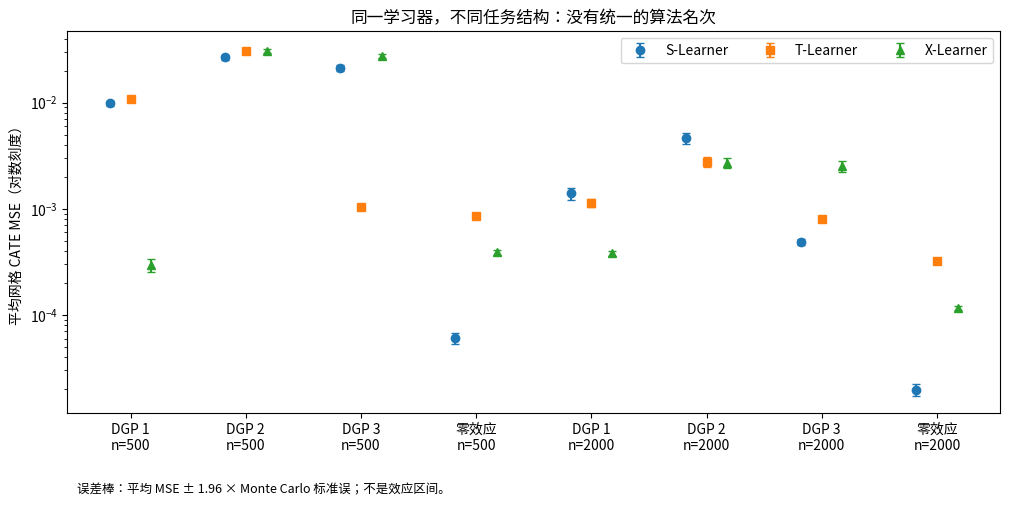

In [12]:
fig, ax = plt.subplots(figsize=(10.2, 5.2))
settings = [(n, mechanism) for n in SAMPLE_SIZES for mechanism in [1, 2, 3, 4]]
pos = np.arange(len(settings))
for j, (name, marker) in enumerate(zip(METHODS, ["o", "s", "^"])):
    means = np.array([mc_summary.loc[(n, m, name), "平均MSE"] for n, m in settings])
    ses = np.array([mc_summary.loc[(n, m, name), "平均MSE的MC标准误"] for n, m in settings])
    ax.errorbar(pos+(j-1)*.18, means, yerr=1.96*ses, fmt=marker, capsize=3,
                label=f"{name}-Learner", linestyle="none")
ax.set_yscale("log")
ax.set_xticks(pos, [f"{'DGP '+str(m) if m < 4 else '零效应'}\nn={n}" for n, m in settings])
ax.set(ylabel="平均网格 CATE MSE（对数刻度）", title="同一学习器，不同任务结构：没有统一的算法名次")
ax.legend(ncol=3)
ax.text(.01, -.21, "误差棒：平均 MSE ± 1.96 × Monte Carlo 标准误；不是效应区间。",
        transform=ax.transAxes, fontsize=9)
fig.tight_layout()
plt.show()

默认的 150 次重复中，500 人的 DGP 1 下，T 与 X 的平均 MSE 约为 0.01077、0.000295；DGP 3 下则约为 0.001036、0.02739。把“X 总是优于 T”写成结论，显然会与后一组结果矛盾。零效应对照中，S 的误差最小：共享模型在这个任务中减少了不必要的波动。

样本变大后也不是所有误差都单调下降。例如 DGP 1 的 X，平均 MSE 从约 0.000295 变为 0.000380。第二阶段仍是可分裂的提升树，并没有被限制为常数；固定这组超参数并不保证有限样本风险单调下降。本表不据此推断 X 的一致性性质，但需要保留这一实际结果，而不是笼统写成“增加样本量后所有方法改善”。

还可以把 CATE 误差拆成两部分。固定评价点 $x$，令 $\overline{\widehat\tau}(x)$ 为重复拟合的平均预测，则有限次重复恰有

$$
\frac1R\sum_r[\widehat\tau_r(x)-\tau(x)]^2
=[\overline{\widehat\tau}(x)-\tau(x)]^2
+\frac1R\sum_r[\widehat\tau_r(x)-\overline{\widehat\tau}(x)]^2.
$$

这是本篇用来核对代码的有限和恒等式。下方只对小样本 DGP 1 的 X-Learner 展示；方差项使用分母 $R$，以便两侧精确相等。曲线范围表示重新抽取训练样本时的预测变化，不是给当前这一份数据计算的置信带。

,平均平方偏差,跨训练样本方差,两者之和,直接平均MSE
0,0.000021,0.000273,0.000295,0.000295


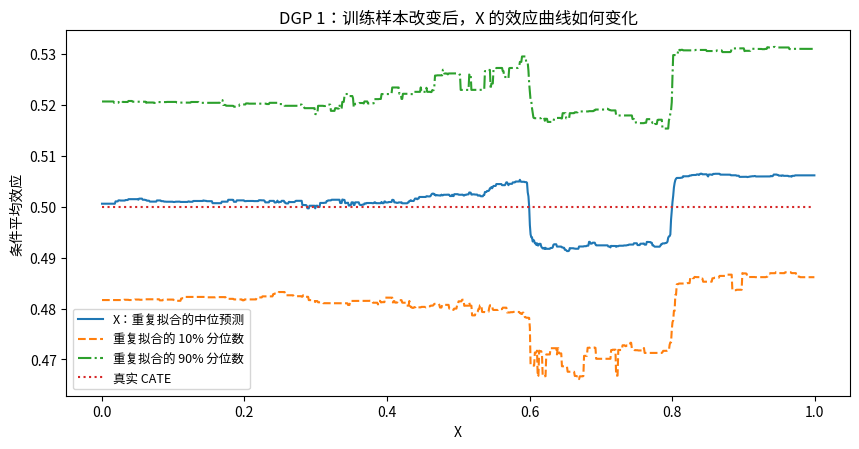

In [13]:
true_curve = book_functions(grid, 1)["tau"]
mean_curve = curve_draws.mean(axis=0)
bias2 = np.mean((mean_curve-true_curve)**2)
variance_part = np.mean(np.var(curve_draws, axis=0, ddof=0))
total_mse = np.mean((curve_draws-true_curve)**2)
display(pd.DataFrame({"平均平方偏差": [bias2], "跨训练样本方差": [variance_part],
                      "两者之和": [bias2+variance_part], "直接平均MSE": [total_mse]}).round(8))
assert np.isclose(bias2+variance_part, total_mse, rtol=1e-12, atol=1e-14)
q10, median_curve, q90 = np.quantile(curve_draws, [.1, .5, .9], axis=0)
fig, ax = plt.subplots(figsize=(8.7, 4.6))
ax.plot(grid[:, 0], median_curve, label="X：重复拟合的中位预测")
ax.plot(grid[:, 0], q10, "--", label="重复拟合的 10% 分位数")
ax.plot(grid[:, 0], q90, "-.", label="重复拟合的 90% 分位数")
ax.plot(grid[:, 0], true_curve, ":", label="真实 CATE")
ax.set(xlabel="X", ylabel="条件平均效应", title="DGP 1：训练样本改变后，X 的效应曲线如何变化")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

### 2. 加上交叉拟合，但不把它当成万能保证

现在回到第一份 DGP 1 数据，查看交叉拟合过程。每个留出者的 $\widehat\mu_0$、$\widehat\mu_1$ 都来自其他折；再将全部训练样本的伪结局汇总，分别训练两个效应模型。测试样本从头到尾不进入这些步骤。

这落实了原书备注 15.1.1 对第一阶段交叉拟合的建议。由于本节是已知概率的随机试验，不需要重新拟合评分。交叉拟合减少结果模型的训练样本数，特别是原本就很小的处理组，因此有限样本下不要求它总能降低 MSE。它也不会让 X 的组合公式突然具有 AIPW 的双重稳健性。[2，第 15.1 节，备注 15.1.1]

,折,训练对照,训练接受者,留出对照,留出接受者
0,1,312,21,157,10
1,2,313,20,156,11
2,3,313,21,156,10


,X,T,Y,留出折,OOF mu0,OOF mu1,伪结局
0,0.7740,0,0.2629,3,0.3202,0.5642,0.3013
1,0.4389,0,0.0462,3,-0.0107,0.5642,0.5179
2,0.8586,0,0.0017,2,-0.0023,0.5770,0.5753
3,0.6974,0,0.2859,1,0.2934,0.6241,0.3382
26,0.4667,1,0.5657,3,-0.0107,0.5642,0.5765
27,0.0438,1,0.4945,2,0.0122,0.4779,0.4823
40,0.4372,1,0.4813,1,0.0047,0.6241,0.4766
43,0.3124,1,0.4383,1,0.0112,0.5028,0.4270


,常规X平均MSE,交叉拟合X平均MSE,配对MSE差,次数,配对差的MC标准误
机制,,,,,
1,0.000374,0.000368,-0.000006,50,0.000020
2,0.030187,0.030302,0.000116,50,0.000060
3,0.026954,0.027055,0.000101,50,0.000077


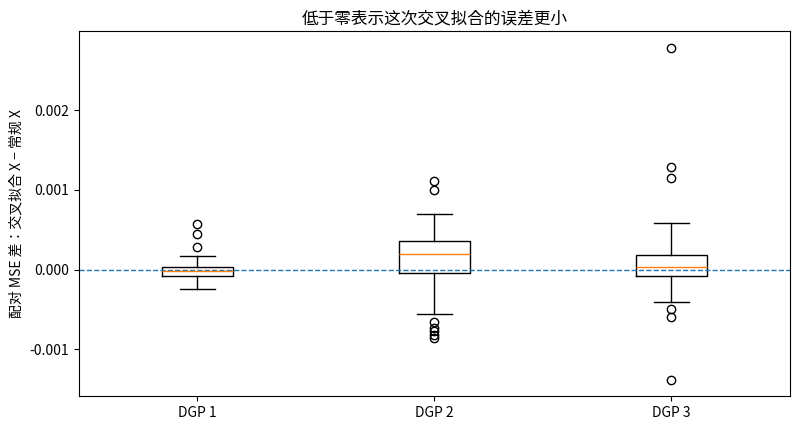

In [14]:
x_cf = fit_x_learner(x, t, y, responses, base_regressor(), base_regressor(), truth["p"],
                     n_folds=N_FOLDS)
display(x_cf["fold_audit"])
cf_trace = observed.iloc[preview_idx].copy()
cf_trace["留出折"] = x_cf["fold_id"][preview_idx]+1
cf_trace["OOF mu0"] = x_cf["m0_for_labels"][preview_idx]
cf_trace["OOF mu1"] = x_cf["m1_for_labels"][preview_idx]
cf_trace["伪结局"] = np.where(t[preview_idx] == 1,
                              y[preview_idx]-x_cf["m0_for_labels"][preview_idx],
                              x_cf["m1_for_labels"][preview_idx]-y[preview_idx])
display(cf_trace.round(4))
cf_summary = cf_comparison.groupby("机制").agg(
    常规X平均MSE=("常规X MSE", "mean"), 交叉拟合X平均MSE=("交叉拟合X MSE", "mean"),
    配对MSE差=("MSE差：交叉拟合减常规", "mean"),
    差的标准差=("MSE差：交叉拟合减常规", "std"), 次数=("重复", "size"),
)
cf_summary["配对差的MC标准误"] = cf_summary["差的标准差"]/np.sqrt(cf_summary["次数"])
display(cf_summary.drop(columns="差的标准差").round(6))
fig, ax = plt.subplots(figsize=(8.1, 4.4))
ax.boxplot([cf_comparison.loc[cf_comparison["机制"] == m, "MSE差：交叉拟合减常规"]
            for m in [1, 2, 3]], tick_labels=["DGP 1", "DGP 2", "DGP 3"], showfliers=True)
ax.axhline(0, linestyle="--", linewidth=1)
ax.set(ylabel="配对 MSE 差：交叉拟合 X − 常规 X", title="低于零表示这次交叉拟合的误差更小")
fig.tight_layout()
plt.show()

50 次配对比较中，三种机制的平均 MSE 差分别约为 −0.000006、0.000116、0.000101，远小于前面不同数据机制带来的误差变化。当前实验没有出现普遍的大幅改善，表中同时保留了配对差的 Monte Carlo 标准误。

表里的 “OOF” 只修饰结果预测。第二阶段模型使用了这些训练行的伪结局，所以它对同一训练行给出的最终 CATE 预测不能因此也叫作折外预测。评价最终函数，仍然需要前面保留的独立测试样本。

### 3. 评分未知时，只让它负责组合

书中例 15.1.1 的评分已知。下面另设一个观察性模拟，把评分改成随特征变化：

$$
X_1,X_2\overset{\mathrm{iid}}\sim U(-1,1),\qquad
e(X)=\operatorname{expit}(-0.5+1.5X_1+X_2),
$$

$$
\mu_0(X)=1+2\sin(\pi X_1)+X_2^2,\qquad
\tau(X)=0.5+X_1-0.5X_2,
$$

$$
Y=\mu_0(X)+T\tau(X)+\varepsilon,\qquad
\varepsilon\sim N(0,0.3^2),\quad T\mid X\sim\operatorname{Bernoulli}(e(X)).
$$

训练结果模型时保留两列特征；评分使用训练样本中的 Logistic 回归估计。这里人为确保了给定完整 $X$ 后无混杂，不据此声称真实观察性数据也满足该条件。它是本篇为演示未知评分增加的例子，不是原书的实证结果。

,测试CATE MSE,平均有符号误差
方法,,
S,0.052611,-0.038722
T,0.022161,0.002212
X：结果交叉拟合,0.008938,-0.004793


处理组人数：1249；对照人数：1751
独立测试集评分 Brier：0.19656
评分与已知概率的测试 RMSE（仅模拟可查）：0.02463


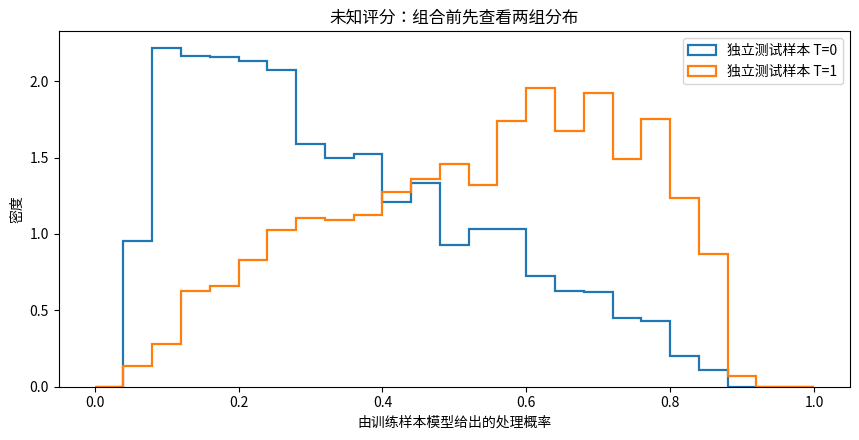

In [15]:
def make_observational_data(n: int, seed: int) -> tuple:
    rng = np.random.default_rng(seed)
    xx = rng.uniform(-1, 1, (n, 2))
    e = expit(-.5+1.5*xx[:, 0]+xx[:, 1])
    m0 = 1+2*np.sin(np.pi*xx[:, 0])+xx[:, 1]**2
    tau = .5+xx[:, 0]-.5*xx[:, 1]
    td = rng.binomial(1, e)
    yd = m0+td*tau+rng.normal(0, .3, n)
    return pd.DataFrame({"X1": xx[:, 0], "X2": xx[:, 1], "T": td, "Y": yd}), {
        "e": e, "mu0": m0, "tau": tau,
    }

obs2, known2 = make_observational_data(N_OBS, SEED_OBS)
test2, true_test2 = make_observational_data(N_TEST, SEED_OBS+1)
x2, t2, y2 = obs2[["X1", "X2"]].to_numpy(), obs2["T"].to_numpy(), obs2["Y"].to_numpy()
x2_test = test2[["X1", "X2"]].to_numpy()
r2 = fit_responses(x2, t2, y2, base_regressor())
ps_template = make_pipeline(StandardScaler(), LogisticRegression(C=1e4, max_iter=2000, tol=1e-8))
x2_model = fit_x_learner(x2, t2, y2, r2, base_regressor(), base_regressor(), ps_template,
                         n_folds=N_FOLDS)
rp2, xp2 = predict_responses(r2, x2_test), predict_x(x2_model, x2_test)
obs_results = pd.DataFrame([
    {"方法": name, "测试CATE MSE": np.mean((pred-true_test2["tau"])**2),
     "平均有符号误差": np.mean(pred-true_test2["tau"])}
    for name, pred in [("S", rp2["S"]), ("T", rp2["T"]), ("X：结果交叉拟合", xp2["X"])]]
)
display(obs_results.set_index("方法").round(6))
print(f"处理组人数：{int(t2.sum())}；对照人数：{int((1-t2).sum())}")
print(f"独立测试集评分 Brier：{np.mean((test2['T'].to_numpy()-xp2['e'])**2):.5f}")
print(f"评分与已知概率的测试 RMSE（仅模拟可查）：{np.sqrt(np.mean((xp2['e']-true_test2['e'])**2)):.5f}")
fig, ax = plt.subplots(figsize=(8.7, 4.5))
for state in [0, 1]:
    mask = test2["T"].to_numpy() == state
    ax.hist(xp2["e"][mask], bins=np.linspace(0, 1, 26), density=True,
            histtype="step", linewidth=1.6, label=f"独立测试样本 T={state}")
ax.set(xlabel="由训练样本模型给出的处理概率", ylabel="密度", title="未知评分：组合前先查看两组分布")
ax.legend()
fig.tight_layout()
plt.show()

默认的观察性模拟中，S、T、交叉拟合 X 的测试 CATE MSE 分别约为 0.05261、0.02216、0.00894。这里的效应函数是线性的，基线结果却是非线性的；它提供了另一个适合 X 分工的例子，但不与前面跳变效应下的排序混为一谈。

评分是在训练样本拟合后，给独立测试者预测的。它不会用测试结局选权重。本例只有结果模型进入训练伪结局的 K 折构造；评分模型不进入该伪结局，只在最终预测新样本时组合两条效应路径。这一点与上一份 IRM 的 AIPW 得分不同。

下面固定 $X_2=0$ 画一个截面。它是 $\tau(x_1,0)$，不是把其余变量平均后的通用定义 $E[\tau(X)\mid X_1=x_1]$。本例因为 $X_2$ 独立、均值为零且线性进入效应，这两条真实曲线恰好相等；换一种结构便不保证如此。

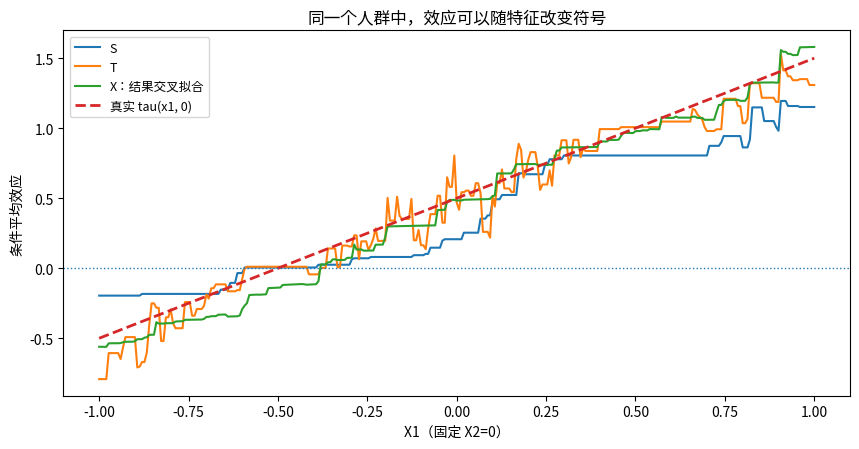

In [16]:
slice_x1 = np.linspace(-1, 1, 301)
slice_x = np.column_stack([slice_x1, np.zeros(len(slice_x1))])
slice_r, slice_p = predict_responses(r2, slice_x), predict_x(x2_model, slice_x)
fig, ax = plt.subplots(figsize=(8.7, 4.6))
for name, pred in [("S", slice_r["S"]), ("T", slice_r["T"]), ("X：结果交叉拟合", slice_p["X"])]:
    ax.plot(slice_x1, pred, label=name)
ax.plot(slice_x1, .5+slice_x1, "--", linewidth=2, label="真实 tau(x1, 0)")
ax.axhline(0, linestyle=":", linewidth=1)
ax.set(xlabel="X1（固定 X2=0）", ylabel="条件平均效应", title="同一个人群中，效应可以随特征改变符号")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

曲线与真实效应的差仍来自结果学习和第二阶段学习；Logistic 概率估计得好，并不意味着 X 的效应也已经估计好。特别在边缘区域，结果模型需要依靠较少的另一组观测。换成更复杂的模型可以尝试改善拟合，但不能代替重叠条件与调整变量的论证。

## 练习

### 练习一：同样使用线性回归，为什么 S 可以不会异质？

回到前面的 12 行小表。比较三个模型：S 的加性线性模型、S 加上全部处理交互、分别拟合两组的 T-Learner。在新特征上计算预测差。

在无惩罚、带组别截距、组内设计矩阵满秩的 OLS 下，全交互 S 的目标函数可以拆成两组各自的平方和，因此它与 T-Learner 产生相同预测。这个代数结论不需要观测噪声为零；但对带惩罚的回归或任意树模型，不再要求有限样本相等。本题是根据前面回归结构设计的计算练习。

In [17]:
# 加性 S：输入 [X, T]；全交互 S：输入 [X, T, X*T]。
s_add = LinearRegression().fit(np.column_stack([xt, tt]), yt)
s_interact = LinearRegression().fit(np.column_stack([xt, tt, xt[:, 0]*tt]), yt)
g = np.linspace(0, 2, 9)[:, None]
s_add0 = s_add.predict(np.column_stack([g, np.zeros(len(g))]))
s_add1 = s_add.predict(np.column_stack([g, np.ones(len(g))]))
s_int0 = s_interact.predict(np.column_stack([g, np.zeros(len(g)), np.zeros(len(g))]))
s_int1 = s_interact.predict(np.column_stack([g, np.ones(len(g)), g[:, 0]]))
solution1 = pd.DataFrame({"X": g[:, 0], "加性S": s_add1-s_add0,
                          "全交互S": s_int1-s_int0,
                          "T": tiny_mu1.predict(g)-tiny_mu0.predict(g),
                          "指定效应": 1+.5*g[:, 0]})
display(solution1.round(5))
assert np.ptp(solution1["加性S"]) < 1e-12
assert np.allclose(solution1["全交互S"], solution1["T"], atol=1e-12)
# 再用深度为 1 的树看另一种限制：强基线变量使这一棵树不使用处理。
z_stump = np.tile(np.linspace(0, 1, 30), 2)
t_stump = np.repeat([0, 1], 30)
y_stump = 20*z_stump+.2*t_stump
stump = DecisionTreeRegressor(max_depth=1, random_state=SEED_LEARNER).fit(
    np.column_stack([z_stump, t_stump]), y_stump)
stump0 = stump.predict(np.column_stack([g[:, 0]/2, np.zeros(len(g))]))
stump1 = stump.predict(np.column_stack([g[:, 0]/2, np.ones(len(g))]))
print(f"树桩第一次分裂的特征索引：{stump.tree_.feature[0]}（0=X，1=T）")
print(f"树桩的全部预测效应：{np.unique(stump1-stump0)}；这里指定的真实效应为 0.2。")
assert np.allclose(stump1-stump0, 0)

,X,加性S,全交互S,T,指定效应
0,0.00,1.5,1.000,1.000,1.000
1,0.25,1.5,1.125,1.125,1.125
2,0.50,1.5,1.250,1.250,1.250
3,0.75,1.5,1.375,1.375,1.375
4,1.00,1.5,1.500,1.500,1.500
5,1.25,1.5,1.625,1.625,1.625
6,1.50,1.5,1.750,1.750,1.750
7,1.75,1.5,1.875,1.875,1.875
8,2.00,1.5,2.000,2.000,2.000


树桩第一次分裂的特征索引：0（0=X，1=T）
树桩的全部预测效应：[0.]；这里指定的真实效应为 0.2。


这两种失败不同：加性线性 S 被结构限定为共同效应；浅树 S 则可能干脆不分裂处理变量。不能把它们都归结为“S-Learner 永远不好”。反过来，在真实零效应时，不使用处理变量未必是缺点。

### 练习二：只按一个变量报告 CATE，能否只调整这个变量？

不一定。原书第 14.1 节先用完整控制集 $Z$ 识别效应，再条件平均到其子集 $X$。按本篇记法，完整控制集为 $X=(V,W)$，只按 $V$ 报告时，应计算

$$
\tau_V(v)=E[\mu_1(V,W)-\mu_0(V,W)\mid V=v].
$$

这不等于直接计算 $E[Y\mid T=1,V=v]-E[Y\mid T=0,V=v]$。后者可能在两个处理组里对 $W$ 使用了不同的分布。[2，第 14.1 节式 (14.1.1)、第 15.1 节 X-Learner 的脚注 4]

构造四个等比例层，$V,W\in\{0,1\}$，未处理均值为 $1+2V+4W$，效应为 $1+V+2W$，处理概率依次为 0.1、0.4、0.6、0.9。请先按 $(V,W)$ 调整，再将两个 $W$ 层按目标人群比例平均，比较只按 $V$ 的组间差。

In [18]:
strata = pd.DataFrame({"V": [0, 0, 1, 1], "W": [0, 1, 0, 1],
                       "总体比例": [.25]*4, "e": [.1, .4, .6, .9]})
strata["mu0"] = 1+2*strata["V"]+4*strata["W"]
strata["tau"] = 1+strata["V"]+2*strata["W"]
strata["mu1"] = strata["mu0"]+strata["tau"]
# 展开的是总体概率质量，不是反复抽样后凑出的平衡样本。
pop_rows = []
for _, row in strata.iterrows():
    for state in [0, 1]:
        pop_rows.append({"V": row["V"], "W": row["W"], "T": state,
                         "Y": row[f"mu{state}"],
                         "质量": row["总体比例"]*(row["e"] if state else 1-row["e"])})
pop = pd.DataFrame(pop_rows)
# 第一阶段控制完整的 (V,W)。此构造的两组均值都是线性的，OLS 可以精确拟合。
pop_mu = {}
for state in [0, 1]:
    part = pop.loc[pop["T"] == state]
    pop_mu[state] = LinearRegression().fit(part[["V", "W"]], part["Y"], sample_weight=part["质量"])
full_effect = pop_mu[1].predict(strata[["V", "W"]])-pop_mu[0].predict(strata[["V", "W"]])
# 第二阶段按总体分布投影到 V，而不是按单个处理组的分布投影。
project_v = LinearRegression().fit(strata[["V"]], full_effect, sample_weight=strata["总体比例"])
exercise_rows = []
for value in [0, 1]:
    group = strata.loc[strata["V"] == value]
    mean1 = np.average(group["mu1"], weights=group["总体比例"]*group["e"])
    mean0 = np.average(group["mu0"], weights=group["总体比例"]*(1-group["e"]))
    effect_treated = np.average(group["tau"], weights=group["总体比例"]*group["e"])
    effect_controls = np.average(group["tau"], weights=group["总体比例"]*(1-group["e"]))
    projected = project_v.predict(pd.DataFrame({"V": [value]}))[0]
    exercise_rows.append({"V": value, "目标CATE": np.average(group["tau"], weights=group["总体比例"]),
                          "完整调整后再平均": projected, "只按V的观察差": mean1-mean0,
                          "接受者内的条件平均效应": effect_treated,
                          "对照内的条件平均效应": effect_controls})
solution2 = pd.DataFrame(exercise_rows).set_index("V")
display(strata.round(3))
display(solution2.round(5))
assert np.allclose(solution2["目标CATE"], [2, 3])
assert np.allclose(solution2["目标CATE"], solution2["完整调整后再平均"])

,V,W,总体比例,e,mu0,tau,mu1
0,0,0,0.25,0.1,1,1,2
1,0,1,0.25,0.4,5,3,8
2,1,0,0.25,0.6,3,2,5
3,1,1,0.25,0.9,7,4,11


,目标CATE,完整调整后再平均,只按V的观察差,接受者内的条件平均效应,对照内的条件平均效应
V,,,,,
0,2.0,2.0,4.2,2.6,1.8
1,3.0,3.0,4.8,3.2,2.4


只按 $V$ 的观察差还包含了 $W$ 的构成差异。最后两列也提醒我们：完整特征 $(V,W)$ 下两条 X 路径有同一条件效应，不代表提前把特征减为 $V$ 后，接受者内与对照内的条件平均效应仍然相等。

因此，效应模型只想保留少量变量时，不能直接把其余混杂变量从结果模型删掉。书中 S/T 的最后一次回归、X 的最终条件平均步骤，正是为了把“完整调整”与“按少量变量表达效应”分开。若实际采用这类两阶段学习，还需在训练数据内部安排第一阶段交叉拟合；本题使用已知总体质量，仅核对识别与平均顺序，不演示有限样本推断。

## 总结与适用范围

S-Learner 共用一个结果模型，T-Learner 分别预测两种结果，X-Learner 再利用补全的伪结局学习效应，并按评分组合两条路径。学习器的复杂度、每组样本量、效应函数是否比结果函数简单，都会改变比较结果。

本篇的三个书中机制保留了同一条经验：先看究竟哪一步难，再决定如何组织学习。X 适合的不是“不平衡”这一个标签，而是人数不平衡与结果／效应复杂度等条件的组合。它不具备 AIPW 意义下的双重稳健性，交叉拟合也不会改变这一点。

在模拟中，我们能够查看真实 CATE，所以可以计算函数误差、分解偏差和方差；在真实数据中，这些真值不可见。S/T/X 给出的每个数仍是条件平均效应预测，不是被观察到的个人反事实，也没有自动附带有效的点态置信区间。

下一篇接着讨论 DR-Learner 与 R-Learner：将 AIPW 伪结局和残差损失用于学习效应函数，而不只是把两种结果相减。

## 参考资料

[1] Peng Ding. *A First Course in Causal Inference*. 用户提供的 `因果推断.pdf`，arXiv:2305.18793v2，2023-10-03。第 2 章的潜在结局，第 10.3 节的 CATE 定义与识别。

[2] Victor Chernozhukov, Christian Hansen, Nathan Kallus, Martin Spindler, Vasilis Syrgkanis. *Applied Causal Inference Powered by ML and AI*. 用户提供的 `CausalML_book_2022.pdf`，实际扉页版本为 0.1.2，2026-05-03。第 14.1 节；第 15.1 节式 (15.1.3)、(15.1.4)、(15.1.9)，例 15.1.1，备注 15.1.1。文中的“第 406 页”等指正文页码，不是 PDF 文件页序。

[3] Sören R. Künzel, Jasjeet S. Sekhon, Peter J. Bickel, Bin Yu. Metalearners for estimating heterogeneous treatment effects using machine learning. *PNAS*, 2019, 116(10): 4156–4165. DOI: 10.1073/pnas.1804597116。作为常规 S/T/X 直接预测形式的补充来源，不替代两本书的章节安排。

[4] EconML 官方文档，Meta-Learners：<https://www.pywhy.org/EconML/spec/estimation/metalearners.html>。用于核对完整特征下的直接 S/T 预测与 X 的组合方向；本篇没有安装或调用 EconML，也不声称完成该软件的逐数值复现。

[5] scikit-learn 官方文档，HistGradientBoostingRegressor：<https://scikit-learn.org/1.8/modules/generated/sklearn.ensemble.HistGradientBoostingRegressor.html>。本次执行使用 scikit-learn 1.8.0；实际版本在初始化单元输出。超参数配置、重复次数、输入检查及全部可视化为本篇实现。